####======================================================
### **Homework Assignment 9**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing 8-pixel x 8-pixel handwritten digits data from *sklearn's digit dataset* to create classifiers to recognize digits 0-9. The dataset contains 1,797 examples (rows) and has 64 features (grayscale value for each pixel).

**The following steps were performed:**

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set (70/30). The X feature matrix was standardized using scaler.

2. Logistic Regression Classifier with Elastic Net Regularization

3. Multi Layer Perceptron (MLP) Neural Network

4. Convolutional Neural Network (CNN)



#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [6]:
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

import sklearn
from sklearn.datasets import load_digits, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import plot_model

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [2]:
digits = load_digits()

digits_df = pd.DataFrame(digits.data, columns=digits.feature_names)

digits_df['label'] = digits.target

digits_df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [3]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=305, stratify=digits.target)

In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1257, 64), (540, 64), (1257,), (540,))

#### ====================================================
#### LOGISTIC REGRESSION CLASSIFIER
#### ======================================================


In [ ]:
# logistic regression with elastic net

lr_param_grid = {
    # regularization strength
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],

    # elastic net mixing parameter
    'l1_ratio': [0.1, 0.5, 0.9],

    # solver that supports elastic net
    'solver': ['saga']
}

# logistic regression classifer with elastic net regularization.

lr_model = LogisticRegression(penalty='elasticnet', max_iter=1000)

# use grid search to find optimal values of the regularization parameters.

lr_grid_search = GridSearchCV(lr_model, lr_param_grid, cv=10, scoring='accuracy', n_jobs=-1)
lr_grid_search.fit(X_train, y_train)


GridSearchCV(cv=10,
             estimator=LogisticRegression(max_iter=1000, penalty='elasticnet'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.9], 'solver': ['saga']},
             scoring='accuracy')

In [ ]:

# find accuracy of trained model on the test data.
lr_y_pred = lr_grid_search.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_y_pred)

# display best logistic regression parameters
print("Best parameters:", lr_grid_search.best_params_)
print("Best accuracy:", lr_grid_search.best_score_)


Best parameters: {'C': 0.05, 'l1_ratio': 0.1, 'solver': 'saga'}
Best accuracy: 0.9681968253968254


#### ====================================================
#### MULTI LAYER PERCEPTRON (MLP)
#### ======================================================

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best configuration: {'hidden_layer_sizes': (64,), 'max_iter': 200}


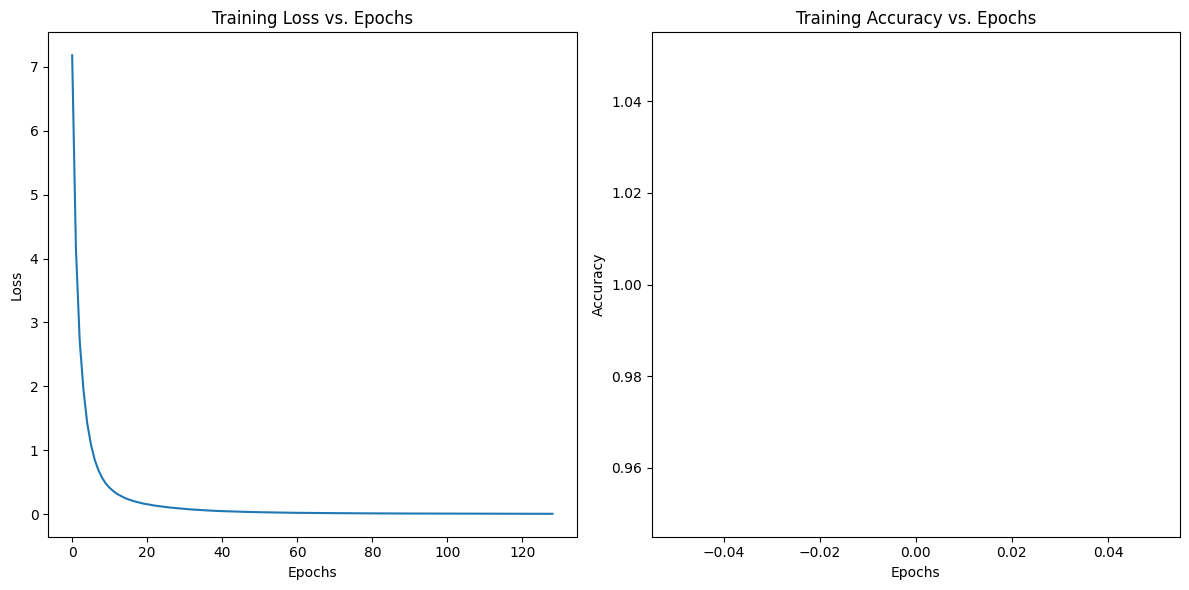

Test Accuracy: 0.9629629629629629


In [7]:
# Define the grid search space for hidden layers and nodes
param_grid = {
    'hidden_layer_sizes': [(n,) for n in [32, 64, 128]],  # 1 hidden layer configuration
    'max_iter': [100, 200],  # Number of iterations (epochs)
}

# Setup GridSearchCV with MLPClassifier
grid_search = GridSearchCV(MLPClassifier(solver='adam', activation='relu', random_state=42),
                           param_grid, cv=3, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model and print the configuration
best_model = grid_search.best_estimator_
print("Best configuration:", grid_search.best_params_)

# Plot the training loss and accuracy vs. epochs
# For that, we will retrieve the history of loss and accuracy during training
loss_values = best_model.loss_curve_

# Plot Training Loss vs. Epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(loss_values)
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Plot Training Accuracy vs. Epochs
# We can estimate accuracy from loss, or we can use validation data for accuracy during training.
# Since we don't have per-epoch accuracy, we'll skip plotting accuracy in GridSearchCV context.

plt.subplot(1, 2, 2)
plt.plot(best_model.score(X_train, y_train))  # This assumes you tracked accuracy per epoch
plt.title('Training Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")